## double taiwanvvm timing

Heatmap column sums (%):
gpus
8     100.0
16    100.0
32    100.0
64    100.0
dtype: float64


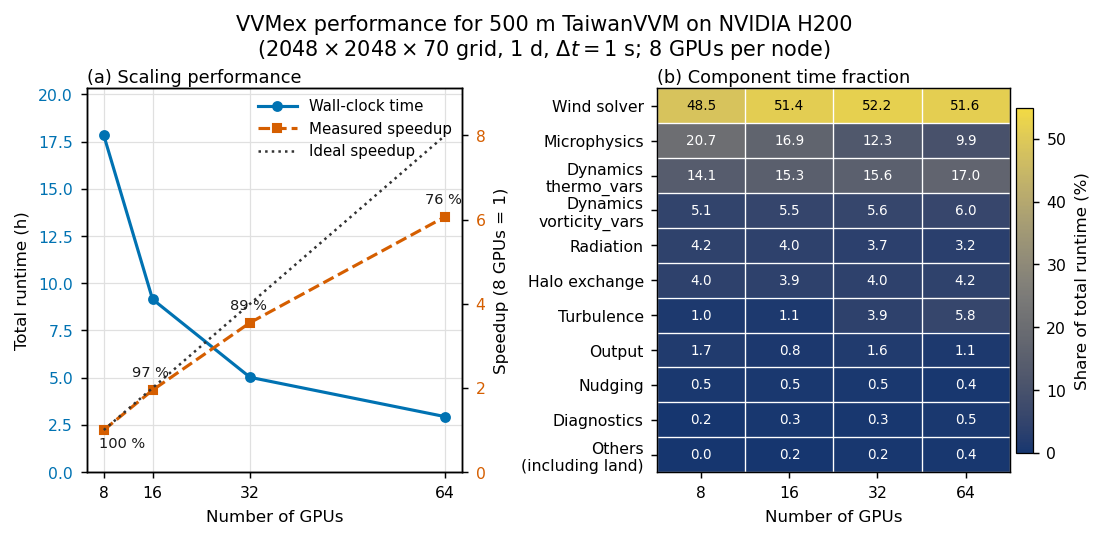

Saved f01_vvm_gpu_timing_gmd.pdf
Saved f01_vvm_gpu_timing_gmd.png


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from pathlib import Path

# ============================================================
# Data: mean_s from timing summaries
# ============================================================

data = [
    # GPUs, component, mean_s
    (8,  "total_vvm", 64182.7327),
    (8,  "dynamics_wind_total", 31102.9425),
    (8,  "microphysics", 13312.5297),
    (8,  "dynamics_thermo", 9026.7011),
    (8,  "dynamics_vorticity", 3302.5842),
    (8,  "radiation", 2672.3222),
    (8,  "halo_exchange", 2550.7065),
    (8,  "io", 1066.4419),
    (8,  "turbulence", 672.3864),
    (8,  "area_mean_nudging", 317.5380),
    (8,  "dynamics_diagnostics", 130.1988),
    (8,  "sponge_layer", 10.1130),
    (8,  "land", 8.0938),
    (8,  "surface", 2.8732),
    (8,  "time_integrator_thermo", 2.6423),
    (8,  "time_integrator_vorticity", 1.0310),
    (8,  "initialize", 1.0240),

    (16, "total_vvm", 32945.6672),
    (16, "dynamics_wind_total", 16934.2224),
    (16, "microphysics", 5568.2048),
    (16, "dynamics_thermo", 5041.9438),
    (16, "dynamics_vorticity", 1820.2466),
    (16, "radiation", 1332.1804),
    (16, "halo_exchange", 1300.1000),
    (16, "turbulence", 361.7414),
    (16, "io", 276.5342),
    (16, "area_mean_nudging", 160.0913),
    (16, "dynamics_diagnostics", 92.4476),
    (16, "initialize", 28.6178),
    (16, "sponge_layer", 12.3597),
    (16, "land", 5.3457),
    (16, "surface", 3.8863),
    (16, "time_integrator_thermo", 3.3751),
    (16, "time_integrator_vorticity", 1.3124),

    (32, "total_vvm", 18070.9018),
    (32, "dynamics_wind_total", 9428.6386),
    (32, "dynamics_thermo", 2817.2723),
    (32, "microphysics", 2229.4000),
    (32, "turbulence", 705.7980),
    (32, "dynamics_vorticity", 1015.8387),
    (32, "halo_exchange", 721.2244),
    (32, "radiation", 669.0310),
    (32, "io", 297.5576),
    (32, "area_mean_nudging", 82.3631),
    (32, "dynamics_diagnostics", 60.6851),
    (32, "initialize", 15.1656),
    (32, "sponge_layer", 12.2113),
    (32, "surface", 3.6668),
    (32, "land", 3.6375),
    (32, "time_integrator_thermo", 3.3336),
    (32, "time_integrator_vorticity", 1.2830),

    (64, "total_vvm", 10578.3102),
    (64, "dynamics_wind_total", 5461.1856),
    (64, "dynamics_thermo", 1800.5622),
    (64, "microphysics", 1048.1131),
    (64, "turbulence", 610.9504),
    (64, "halo_exchange", 440.5926),
    (64, "dynamics_vorticity", 631.8437),
    (64, "radiation", 333.6015),
    (64, "io", 114.8697),
    (64, "dynamics_diagnostics", 49.9471),
    (64, "area_mean_nudging", 43.9453),
    (64, "initialize", 17.1926),
    (64, "sponge_layer", 11.8622),
    (64, "surface", 3.3796),
    (64, "time_integrator_thermo", 3.2361),
    (64, "land", 2.7421),
    (64, "time_integrator_vorticity", 1.2436),
]

# ============================================================
# Convert to dataframe
# ============================================================

df = pd.DataFrame(data, columns=["gpus", "component", "mean_s"])
wide = df.pivot(index="gpus", columns="component", values="mean_s").sort_index()

gpus = wide.index.to_numpy()
total_s = wide["total_vvm"]
total_h = total_s / 3600.0

# ============================================================
# Scaling metrics
# ============================================================

baseline_gpu = 8
baseline_total_s = total_s.loc[baseline_gpu]

speedup = baseline_total_s / total_s
ideal_speedup = gpus / baseline_gpu
parallel_efficiency = speedup / ideal_speedup

# ============================================================
# GMD-oriented plot style
# ============================================================
# - Single sans-serif font family.
# - TrueType font embedding in vector outputs.
# - Color-vision-deficiency-friendly line colors based on Okabe-Ito.
# - CVD-friendly sequential heatmap using cividis, lightly truncated to avoid
#   excessively dark near-zero cells.
# - No long figure title: case details belong in the manuscript caption.

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.0,
    "axes.labelsize": 8.0,
    "axes.titlesize": 8.5,
    "legend.fontsize": 7.2,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
})

# Okabe-Ito palette: generally robust for common CVD cases.
runtime_color = "#0072B2"  # blue
speedup_color = "#D55E00"  # vermilion
ideal_color = "0.20"

base_cmap = mpl.colormaps["cividis"]
heatmap_cmap = LinearSegmentedColormap.from_list(
    "cividis_truncated",
    base_cmap(np.linspace(0.12, 0.95, 256)),
)
heatmap_norm = Normalize(vmin=0.0, vmax=55.0)

# ============================================================
# Heatmap data
# ============================================================

main_components = [
    "dynamics_wind_total",
    "microphysics",
    "dynamics_thermo",
    "dynamics_vorticity",
    "radiation",
    "halo_exchange",
    "turbulence",
    "io",
    "area_mean_nudging",
    "dynamics_diagnostics",
]

shown_sum_s = wide[main_components].sum(axis=1)
others_s = total_s - shown_sum_s

if (others_s < -1e-6).any():
    print("Warning: selected component timers exceed total_vvm.")
    print("This suggests overlapping or inclusive timers.")
    print(others_s)

others_s = others_s.clip(lower=0.0)

wide_for_heatmap = wide[main_components].copy()
wide_for_heatmap["others"] = others_s

components_for_heatmap = main_components + ["others"]
component_fraction = wide_for_heatmap.div(total_s, axis=0) * 100.0
heatmap_data = component_fraction[components_for_heatmap].T

print("Heatmap column sums (%):")
print(heatmap_data.sum(axis=0).round(3))

component_labels = {
    "dynamics_wind_total": "Wind solver",
    "microphysics": "Microphysics",
    "dynamics_thermo": "Dynamics\nthermo_vars",
    "dynamics_vorticity": "Dynamics\nvorticity_vars",
    "radiation": "Radiation",
    "halo_exchange": "Halo exchange",
    "turbulence": "Turbulence",
    "io": "Output",
    "area_mean_nudging": "Nudging",
    "dynamics_diagnostics": "Diagnostics",
    "others": "Others\n(including land)",
}



cm = 1 / 2.54
fig = plt.figure(figsize=(18.0 * cm, 10 * cm), constrained_layout=False)


gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.00, 1.0],
    wspace=0.52,
)

# ============================================================
# Panel (a): total runtime and speedup
# ============================================================

ax1 = fig.add_subplot(gs[0, 0])

line_runtime, = ax1.plot(
    gpus,
    total_h,
    marker="o",
    linewidth=1.5,
    markersize=4.2,
    color=runtime_color,
    label="Wall-clock time",
)

ax1.set_xlabel("Number of GPUs")
ax1.set_ylabel("Total runtime (h)")
ax1.set_xticks(gpus)
ax1.set_title("(a) Scaling performance", loc="left", pad=3)
ax1.grid(True, color="0.88", linewidth=0.6)
ax1.set_ylim(0, total_h.max() * 1.14)
ax1.tick_params(axis="y", labelcolor=runtime_color)

ax1b = ax1.twinx()

line_speedup, = ax1b.plot(
    gpus,
    speedup,
    marker="s",
    linewidth=1.5,
    markersize=4.0,
    linestyle="--",
    color=speedup_color,
    label="Measured speedup",
)

line_ideal, = ax1b.plot(
    gpus,
    ideal_speedup,
    linewidth=1.2,
    linestyle=":",
    color=ideal_color,
    label="Ideal speedup",
)

ax1b.set_ylabel("Speedup (8 GPUs = 1)")
ax1b.set_ylim(0, ideal_speedup.max() * 1.14)
ax1b.tick_params(axis="y", labelcolor=speedup_color)

# Keep axis spines neutral. The color coding is only on tick labels and curves.
for ax in [ax1, ax1b]:
    for spine in ["left", "right", "top", "bottom"]:
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.7)

# Parallel-efficiency labels; use a space before the percent sign.
for x, y, eff in zip(gpus, speedup, parallel_efficiency):
    dx = 20 if x == baseline_gpu else -1
    dy = -10 if x == baseline_gpu else 5
    ha = "right" if x == baseline_gpu else "center"
    ax1b.annotate(
        f"{eff * 100:.0f} %",
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va="bottom",
        fontsize=7.0,
        color="0.10",
    )

# Legend inside the figure, with explicit symbols and line styles.
ax1.legend(
    [line_runtime, line_speedup, line_ideal],
    ["Wall-clock time", "Measured speedup", "Ideal speedup"],
    loc="upper right",
    frameon=False,
    handlelength=2.6,
    borderpad=0.2,
)

# ============================================================
# Panel (b): component fraction heatmap
# ============================================================

ax2 = fig.add_subplot(gs[0, 1])

im = ax2.imshow(
    heatmap_data,
    aspect="auto",
    origin="upper",
    cmap=heatmap_cmap,
    norm=heatmap_norm,
)

ax2.set_xticks(np.arange(len(gpus)))
ax2.set_xticklabels(gpus)
ax2.set_yticks(np.arange(len(components_for_heatmap)))
ax2.set_yticklabels([component_labels[c] for c in components_for_heatmap])
ax2.set_xlabel("Number of GPUs")
ax2.set_title("(b) Component time fraction", loc="left", pad=3)

# Cell grid lines.
ax2.set_xticks(np.arange(-0.5, len(gpus), 1), minor=True)
ax2.set_yticks(np.arange(-0.5, len(components_for_heatmap), 1), minor=True)
ax2.grid(which="minor", color="white", linestyle="-", linewidth=0.65)
ax2.tick_params(which="minor", bottom=False, left=False)

# Colorbar with unit in the label. Ticks stay numeric to reduce clutter.
cbar = fig.colorbar(im, ax=ax2, pad=0.016, fraction=0.046)
cbar.set_label("Share of total runtime (%)")
cbar.set_ticks([0, 10, 20, 30, 40, 50])
cbar.outline.set_linewidth(0.6)

# Cell labels with automatic contrast for readability.
for i in range(len(components_for_heatmap)):
    for j in range(len(gpus)):
        value = heatmap_data.iloc[i, j]
        rgba = heatmap_cmap(heatmap_norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.50 else "white"
        ax2.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=6.5,
            color=text_color,
        )

for ax in [ax1, ax2]:
    ax.tick_params(direction="out")

# fig.subplots_adjust(
#     left=0.075,
#     right=0.970,
#     top=0.925,
#     bottom=0.175,
# )

fig.suptitle(
    "VVMex performance for 500 m TaiwanVVM on NVIDIA H200\n"
    r"($2048 \times 2048 \times 70$ grid, 1 d, $\Delta t = 1$ s; 8 GPUs per node)",
    fontsize=10,
    fontweight="normal",
    y=0.975,
    linespacing=1.15,
)

fig.subplots_adjust(
    left=0.07,
    right=0.96,
    top=0.85,
    bottom=0.20,
)



# ============================================================
# Save journal-ready outputs
# ============================================================

out_dir = Path("./")
pdf_path = out_dir / "f01_vvm_gpu_timing_gmd.pdf"
png_path = out_dir / "f01_vvm_gpu_timing_gmd.png"

fig.savefig(pdf_path, bbox_inches="tight", metadata={"Creator": "Matplotlib"})
fig.savefig(png_path, bbox_inches="tight")

plt.show()

plt.close(fig)

print(f"Saved {pdf_path}")
print(f"Saved {png_path}")


## Float TaiwanVVM timing

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


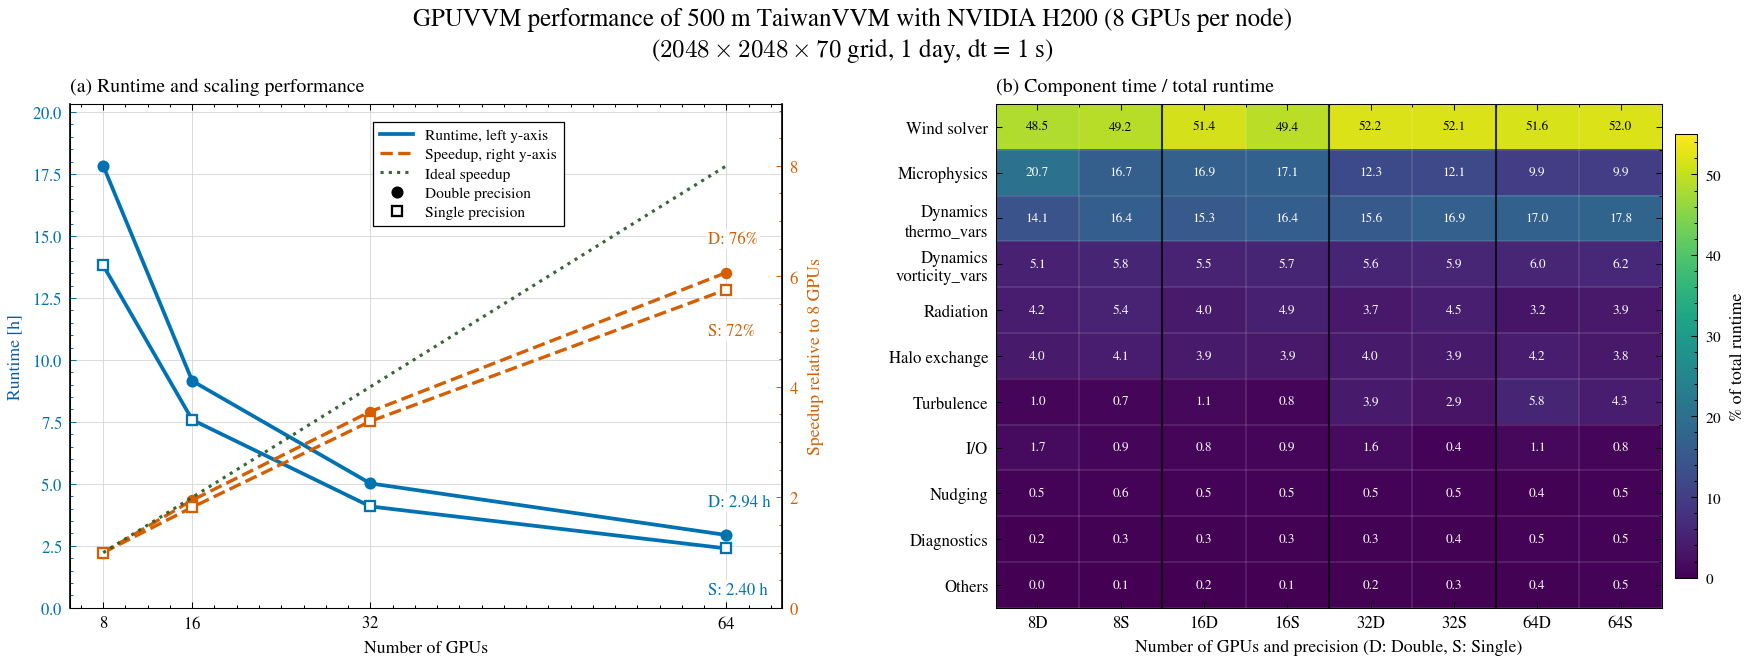

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scienceplots

from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ============================================================
# SciencePlots style
# ============================================================

# Use "science" style, avoid requiring a LaTeX installation,
# and keep Matplotlib's default color cycle.
plt.style.use(["science", "no-latex", "std-colors"])

# ============================================================
# Double-precision timing data: mean_s
# ============================================================

data_double = [
    # 8 GPUs
    (8,  "total_vvm", 64182.7327),
    (8,  "dynamics_wind_total", 31102.9425),
    (8,  "microphysics", 13312.5297),
    (8,  "dynamics_thermo", 9026.7011),
    (8,  "dynamics_vorticity", 3302.5842),
    (8,  "radiation", 2672.3222),
    (8,  "halo_exchange", 2550.7065),
    (8,  "io", 1066.4419),
    (8,  "turbulence", 672.3864),
    (8,  "area_mean_nudging", 317.5380),
    (8,  "dynamics_diagnostics", 130.1988),
    (8,  "sponge_layer", 10.1130),
    (8,  "land", 8.0938),
    (8,  "surface", 2.8732),
    (8,  "time_integrator_thermo", 2.6423),
    (8,  "time_integrator_vorticity", 1.0310),
    (8,  "initialize", 1.0240),

    # 16 GPUs
    (16, "total_vvm", 32945.6672),
    (16, "dynamics_wind_total", 16934.2224),
    (16, "microphysics", 5568.2048),
    (16, "dynamics_thermo", 5041.9438),
    (16, "dynamics_vorticity", 1820.2466),
    (16, "radiation", 1332.1804),
    (16, "halo_exchange", 1300.1000),
    (16, "turbulence", 361.7414),
    (16, "io", 276.5342),
    (16, "area_mean_nudging", 160.0913),
    (16, "dynamics_diagnostics", 92.4476),
    (16, "initialize", 28.6178),
    (16, "sponge_layer", 12.3597),
    (16, "land", 5.3457),
    (16, "surface", 3.8863),
    (16, "time_integrator_thermo", 3.3751),
    (16, "time_integrator_vorticity", 1.3124),

    # 32 GPUs
    (32, "total_vvm", 18070.9018),
    (32, "dynamics_wind_total", 9428.6386),
    (32, "dynamics_thermo", 2817.2723),
    (32, "microphysics", 2229.4000),
    (32, "turbulence", 705.7980),
    (32, "dynamics_vorticity", 1015.8387),
    (32, "halo_exchange", 721.2244),
    (32, "radiation", 669.0310),
    (32, "io", 297.5576),
    (32, "area_mean_nudging", 82.3631),
    (32, "dynamics_diagnostics", 60.6851),
    (32, "initialize", 15.1656),
    (32, "sponge_layer", 12.2113),
    (32, "surface", 3.6668),
    (32, "land", 3.6375),
    (32, "time_integrator_thermo", 3.3336),
    (32, "time_integrator_vorticity", 1.2830),

    # 64 GPUs
    (64, "total_vvm", 10578.3102),
    (64, "dynamics_wind_total", 5461.1856),
    (64, "dynamics_thermo", 1800.5622),
    (64, "microphysics", 1048.1131),
    (64, "turbulence", 610.9504),
    (64, "halo_exchange", 440.5926),
    (64, "dynamics_vorticity", 631.8437),
    (64, "radiation", 333.6015),
    (64, "io", 114.8697),
    (64, "dynamics_diagnostics", 49.9471),
    (64, "area_mean_nudging", 43.9453),
    (64, "initialize", 17.1926),
    (64, "sponge_layer", 11.8622),
    (64, "surface", 3.3796),
    (64, "time_integrator_thermo", 3.2361),
    (64, "land", 2.7421),
    (64, "time_integrator_vorticity", 1.2436),
]

# ============================================================
# Single-precision (Float) timing data: mean_s
# ============================================================

data_single = [
    # 8 GPUs
    (8,  "total_vvm", 49711.6329),
    (8,  "dynamics_wind_total", 24451.9266),
    (8,  "microphysics", 8283.4671),
    (8,  "dynamics_thermo", 8142.3677),
    (8,  "dynamics_vorticity", 2877.4454),
    (8,  "radiation", 2661.4520),
    (8,  "halo_exchange", 2055.5238),
    (8,  "io", 471.2962),
    (8,  "turbulence", 331.2486),
    (8,  "area_mean_nudging", 283.7810),
    (8,  "dynamics_diagnostics", 126.2057),
    (8,  "sponge_layer", 9.6868),
    (8,  "land", 7.2986),
    (8,  "surface", 3.6293),
    (8,  "time_integrator_thermo", 2.5353),
    (8,  "time_integrator_vorticity", 0.9815),
    (8,  "initialize", 1.0379),

    # 16 GPUs
    (16, "total_vvm", 27299.8989),
    (16, "dynamics_wind_total", 13488.9825),
    (16, "microphysics", 4661.0992),
    (16, "dynamics_thermo", 4471.9975),
    (16, "dynamics_vorticity", 1561.1349),
    (16, "radiation", 1335.5614),
    (16, "halo_exchange", 1051.9838),
    (16, "turbulence", 216.6505),
    (16, "io", 252.6309),
    (16, "area_mean_nudging", 143.3317),
    (16, "dynamics_diagnostics", 83.0447),
    (16, "sponge_layer", 11.8476),
    (16, "initialize", 5.6370),
    (16, "land", 4.5384),
    (16, "time_integrator_thermo", 3.2247),
    (16, "surface", 3.1675),
    (16, "time_integrator_vorticity", 1.2664),

    # 32 GPUs
    (32, "total_vvm", 14725.5093),
    (32, "dynamics_wind_total", 7671.5630),
    (32, "dynamics_thermo", 2481.5315),
    (32, "microphysics", 1783.2503),
    (32, "dynamics_vorticity", 875.2034),
    (32, "turbulence", 430.0675),
    (32, "halo_exchange", 578.9501),
    (32, "radiation", 667.8398),
    (32, "area_mean_nudging", 73.5925),
    (32, "io", 64.9300),
    (32, "dynamics_diagnostics", 54.1583),
    (32, "initialize", 18.5572),
    (32, "sponge_layer", 12.0789),
    (32, "surface", 3.2657),
    (32, "time_integrator_thermo", 3.2829),
    (32, "land", 3.2263),
    (32, "time_integrator_vorticity", 1.2730),

    # 64 GPUs
    (64, "total_vvm", 8629.7040),
    (64, "dynamics_wind_total", 4487.5222),
    (64, "dynamics_thermo", 1534.0551),
    (64, "microphysics", 853.2177),
    (64, "turbulence", 370.8810),
    (64, "dynamics_vorticity", 530.8676),
    (64, "halo_exchange", 329.6876),
    (64, "radiation", 333.2624),
    (64, "io", 67.2862),
    (64, "dynamics_diagnostics", 41.9155),
    (64, "area_mean_nudging", 39.0683),
    (64, "initialize", 17.1069),
    (64, "sponge_layer", 11.7397),
    (64, "surface", 3.1785),
    (64, "time_integrator_thermo", 3.1966),
    (64, "land", 2.4488),
    (64, "time_integrator_vorticity", 1.2341),
]

# ============================================================
# Additional figure settings
# ============================================================

mpl.rcParams.update({
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "axes.titlesize": 9.5,
    "legend.fontsize": 7.4,
    "legend.title_fontsize": 7.4,
    "xtick.labelsize": 8.0,
    "ytick.labelsize": 8.0,
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# Visual encoding
# ============================================================

# runtime_color = "C0"
# speedup_color = "C1"
runtime_color = "#0072B2"
speedup_color = "#D55E00"
# runtime_color = "#003366"
# speedup_color = "#b30000"


ideal_color = "#2E5E2E"

double_marker = "o"
single_marker = "s"

runtime_axis_color = "C0"
speedup_axis_color = "C1"

grid_color = "0.82"

heatmap_cmap = mpl.colormaps["viridis"]
heatmap_norm = Normalize(vmin=0, vmax=55)

# ============================================================
# Component selection
# ============================================================

main_components = [
    "dynamics_wind_total",
    "microphysics",
    "dynamics_thermo",
    "dynamics_vorticity",
    "radiation",
    "halo_exchange",
    "turbulence",
    "io",
    "area_mean_nudging",
    "dynamics_diagnostics",
]

component_labels = {
    "dynamics_wind_total": "Wind solver",
    "microphysics": "Microphysics",
    "dynamics_thermo": "Dynamics\nthermo_vars",
    "dynamics_vorticity": "Dynamics\nvorticity_vars",
    "radiation": "Radiation",
    "halo_exchange": "Halo exchange",
    "turbulence": "Turbulence",
    "io": "I/O",
    "area_mean_nudging": "Nudging",
    "dynamics_diagnostics": "Diagnostics",
    "others": "Others",
}

# ============================================================
# Helper functions
# ============================================================

def make_wide(data):
    df = pd.DataFrame(data, columns=["gpus", "component", "mean_s"])
    wide = df.pivot(index="gpus", columns="component", values="mean_s").sort_index()
    return wide


def compute_scaling(wide, baseline_gpu=8):
    gpus = wide.index.to_numpy()
    total_s = wide["total_vvm"]
    total_hr = total_s / 3600.0

    baseline_total_s = total_s.loc[baseline_gpu]
    speedup = baseline_total_s / total_s
    ideal_speedup = pd.Series(gpus / baseline_gpu, index=wide.index)
    efficiency = speedup / ideal_speedup

    return gpus, total_hr, speedup, ideal_speedup, efficiency


def compute_heatmap(wide):
    total_s = wide["total_vvm"]

    shown_sum_s = wide[main_components].sum(axis=1)
    others_s = total_s - shown_sum_s

    others_s = others_s.clip(lower=0.0)

    wide_for_heatmap = wide[main_components].copy()
    wide_for_heatmap["others"] = others_s

    components = main_components + ["others"]
    heatmap = wide_for_heatmap.div(total_s, axis=0) * 100.0
    heatmap = heatmap[components].T

    return heatmap, components


def combine_heatmaps(heatmap_double, heatmap_single):
    combined = pd.DataFrame(index=heatmap_double.index)

    for gpu in heatmap_double.columns:
        combined[f"{gpu}D"] = heatmap_double[gpu]
        # Changed 'F' to 'S' to represent Single precision
        combined[f"{gpu}S"] = heatmap_single[gpu]

    return combined


def text_color_for_heatmap_value(value, cmap, norm):
    rgba = cmap(norm(value))
    r, g, b = rgba[:3]
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.55 else "white"

# ============================================================
# Prepare data
# ============================================================

wide_double = make_wide(data_double)
wide_single = make_wide(data_single)

gpus_d, total_hr_d, speedup_d, ideal_speedup_d, eff_d = compute_scaling(wide_double)
gpus_s, total_hr_s, speedup_s, ideal_speedup_s, eff_s = compute_scaling(wide_single)

heatmap_double, components = compute_heatmap(wide_double)
heatmap_single, _ = compute_heatmap(wide_single)
heatmap_combined = combine_heatmaps(heatmap_double, heatmap_single)

# ============================================================
# Figure layout: panel (a) left, panel (b) right
# ============================================================

fig = plt.figure(figsize=(12.0, 4.8)) # Slightly increased height for subtitle

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.00, 1.00],
    wspace=0.30,
)

# Added experimental details into the suptitle
fig.suptitle(
    f"GPUVVM performance of 500 m TaiwanVVM with NVIDIA H200 (8 GPUs per node)\n" + r"($2048 \times 2048 \times 70$ grid, 1 day, dt = 1 s)",
    fontsize=12,
    y=0.98,
)

# ============================================================
# Panel (a): runtime and scaling
# ============================================================

ax_runtime = fig.add_subplot(gs[0, 0])

ax_runtime.plot(
    gpus_d,
    total_hr_d,
    marker=double_marker,
    linewidth=1.8,
    markersize=4.8,
    linestyle="-",
    color=runtime_color,
    markerfacecolor=runtime_color,
    markeredgecolor=runtime_color,
)

ax_runtime.plot(
    gpus_s,
    total_hr_s,
    marker=single_marker,
    linewidth=1.8,
    markersize=4.8,
    linestyle="-",
    color=runtime_color,
    markerfacecolor="white",
    markeredgecolor=runtime_color,
    markeredgewidth=1.1,
)

ax_runtime.set_title("(a) Runtime and scaling performance", loc="left", pad=6)
ax_runtime.set_xlabel("Number of GPUs")
ax_runtime.set_ylabel("Runtime [h]", color=runtime_axis_color)
ax_runtime.set_xticks(gpus_d)
ax_runtime.set_xlim(gpus_d.min() - 3, gpus_d.max() + 5)
ax_runtime.set_ylim(0, max(total_hr_d.max(), total_hr_s.max()) * 1.14)

ax_runtime.tick_params(axis="y", colors=runtime_color, which="both")
ax_runtime.tick_params(axis="x", colors="black", which="both")

ax_runtime.spines["left"].set_color("black")
ax_runtime.spines["left"].set_linewidth(0.8)
ax_runtime.spines["bottom"].set_color("black")
ax_runtime.spines["top"].set_color("black")

ax_runtime.grid(True, which="major", color=grid_color, linewidth=0.5, alpha=0.75)

# Speedup: right y-axis
ax_speedup = ax_runtime.twinx()

ax_speedup.plot(
    gpus_d,
    speedup_d,
    marker=double_marker,
    linewidth=1.6,
    markersize=4.5,
    linestyle="--",
    color=speedup_color,
    markerfacecolor=speedup_color,
    markeredgecolor=speedup_color,
)

ax_speedup.plot(
    gpus_s,
    speedup_s,
    marker=single_marker,
    linewidth=1.6,
    markersize=4.5,
    linestyle="--",
    color=speedup_color,
    markerfacecolor="white",
    markeredgecolor=speedup_color,
    markeredgewidth=1.1,
)

ax_speedup.plot(
    gpus_d,
    ideal_speedup_d,
    linewidth=1.5,
    linestyle=":",
    color=ideal_color,
    alpha=0.95,
)

ax_speedup.set_ylabel("Speedup relative to 8 GPUs", color=speedup_color)
ax_speedup.set_ylim(0, ideal_speedup_d.max() * 1.14)

ax_speedup.tick_params(axis="y", colors=speedup_color, which="both")
ax_speedup.spines["right"].set_color("black")
ax_speedup.spines["right"].set_linewidth(0.8)
ax_speedup.spines["top"].set_color("black")
ax_speedup.spines["bottom"].set_color("black")

# ------------------------------------------------------------
# End-point annotations (Updated F to S)
# ------------------------------------------------------------

label_box = dict(
    boxstyle="round,pad=0.12",
    facecolor="white",
    edgecolor="none",
    alpha=0.85,
)

minus = 5
ax_runtime.annotate(
    f"D: {total_hr_d.iloc[-1]:.2f} h",
    xy=(gpus_d[-1]-minus, total_hr_d.iloc[-1]),
    xytext=(18, 12),
    textcoords="offset points",
    ha="left",
    va="bottom",
    color=runtime_color,
    fontsize=8.0,
    bbox=label_box,
    annotation_clip=False,
)

ax_runtime.annotate(
    f"S: {total_hr_s.iloc[-1]:.2f} h",
    xy=(gpus_s[-1]-minus, total_hr_s.iloc[-1]),
    xytext=(18, -16),
    textcoords="offset points",
    ha="left",
    va="top",
    color=runtime_color,
    fontsize=8.0,
    bbox=label_box,
    annotation_clip=False,
)

ax_speedup.annotate(
    f"D: {eff_d.iloc[-1] * 100:.0f}%",
    xy=(gpus_d[-1]-minus, speedup_d.iloc[-1]),
    xytext=(18, 12),
    textcoords="offset points",
    ha="left",
    va="bottom",
    color=speedup_color,
    fontsize=8.0,
    bbox=label_box,
    annotation_clip=False,
)

ax_speedup.annotate(
    f"S: {eff_s.iloc[-1] * 100:.0f}%",
    xy=(gpus_s[-1]-minus, speedup_s.iloc[-1]),
    xytext=(18, -16),
    textcoords="offset points",
    ha="left",
    va="top",
    color=speedup_color,
    fontsize=8.0,
    bbox=label_box,
    annotation_clip=False,
)


legend_handles = [
    Line2D([0], [0], color=runtime_color, lw=1.8, linestyle="-", label="Runtime, left y-axis"),
    Line2D([0], [0], color=speedup_color, lw=1.6, linestyle="--", label="Speedup, right y-axis"),
    Line2D([0], [0], color=ideal_color, lw=1.5, linestyle=":", alpha=0.95, label="Ideal speedup"),
    Line2D([0], [0], color="black", marker=double_marker, markerfacecolor="black", markeredgecolor="black", lw=0, markersize=4.8, label="Double precision"),
    Line2D([0], [0], color="black", marker=single_marker, markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.1, lw=0, markersize=4.8, label="Single precision"),
]

legend = ax_runtime.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.56, 0.98),
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="black",
    borderpad=0.45,
    labelspacing=0.35,
    handlelength=2.1,
)

legend.get_frame().set_linewidth(0.6)

# ============================================================
# Panel (b): compact combined heatmap
# ============================================================

ax_heat = fig.add_subplot(gs[0, 1])

im = ax_heat.imshow(
    heatmap_combined,
    aspect="auto",
    origin="upper",
    cmap=heatmap_cmap,
    norm=heatmap_norm,
)

ax_heat.set_title("(b) Component time / total runtime", loc="left", pad=6)

# Explicitly defining D and S in the x-axis label
ax_heat.set_xlabel("Number of GPUs and precision (D: Double, S: Single)")
ax_heat.set_ylabel("")

xlabels = []
for col in heatmap_combined.columns:
    gpu = col[:-1]
    precision = col[-1]
    xlabels.append(f"{gpu}{precision}")

ax_heat.set_xticks(np.arange(len(heatmap_combined.columns)))
ax_heat.set_xticklabels(xlabels)

ax_heat.set_yticks(np.arange(len(components)))
ax_heat.set_yticklabels([component_labels[c] for c in components])

ax_heat.set_xticks(np.arange(-0.5, len(heatmap_combined.columns), 1), minor=True)
ax_heat.set_yticks(np.arange(-0.5, len(components), 1), minor=True)
ax_heat.grid(which="minor", color="white", linestyle="-", linewidth=0.1)
ax_heat.tick_params(which="minor", bottom=False, left=False)

for x in [1.5, 3.5, 5.5]:
    ax_heat.axvline(x=x, color="black", linewidth=1.0, alpha=0.8)

for i in range(len(components)):
    for j in range(len(heatmap_combined.columns)):
        value = heatmap_combined.iloc[i, j]
        ax_heat.text(
            j, i, f"{value:.1f}",
            ha="center", va="center", fontsize=6.4,
            color=text_color_for_heatmap_value(value, heatmap_cmap, heatmap_norm),
        )

cbar = fig.colorbar(im, ax=ax_heat, pad=0.018, fraction=0.046, shrink=0.88)
cbar.set_label("% of total runtime")
cbar.set_ticks([0, 10, 20, 30, 40, 50])
cbar.ax.tick_params(labelsize=7.3)

# ============================================================
# Final layout and save
# ============================================================

# Adjusted top to accommodate the multi-line suptitle
fig.subplots_adjust(
    left=0.065,
    right=0.975,
    top=0.845, 
    bottom=0.145,
)

plt.savefig("vvm_gpu_scaling_timing_single_double_science.pdf", bbox_inches="tight")
plt.savefig("vvm_gpu_scaling_timing_single_double_science.png", bbox_inches="tight")
plt.show()